**Polynomial Regression**

What is it? ==> Linear Regression draws a straight line.
But what if relationship between input and output is a curve?
Polynomial Regression draws a curved line to fit the data better.

**Real example:**

Car speed during acceleration — not linear, it curves
Plant growth over time — grows fast then slows down
House price vs size — after certain size, price increase slows

**How it Works**
- Linear: y = m×x + c
- Polynomial degree 2: y = m1×x² + m2×x + c
- Polynomial degree 3: y = m1×x³ + m2×x² + m3×x + c

Higher degree = more curves = fits data better BUT risk of overfitting.

**Key Concept — PolynomialFeatures -**>

Sklearn does not have a separate Polynomial Regression class.
Instead you use PolynomialFeatures to transform your features first — then apply Linear Regression on transformed features.

Original feature: [x]\
After degree 2 transform: [1, x, x²]\
After degree 3 transform: [1, x, x², x³]\
Linear Regression then finds best coefficients for these transformed features.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

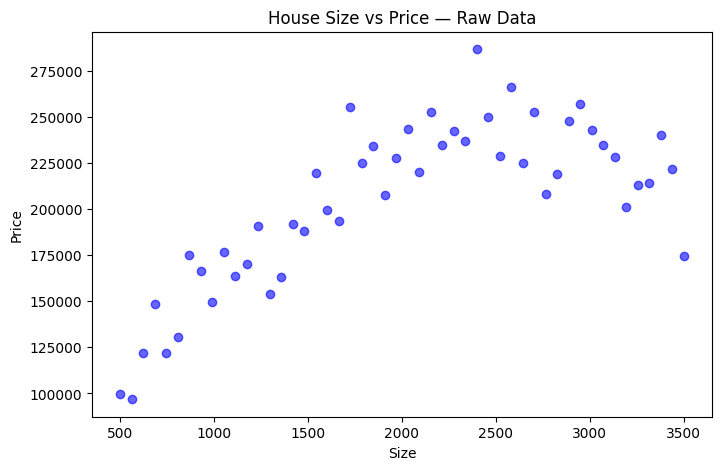

In [32]:
# Dataset — non linear relationship
# House size vs price — price grows but slows at larger sizes

np.random.seed(42)
size  = np.linspace(500, 3500, 50)
price = 200*size - 0.04*size**2 + np.random.normal(0, 20000, 50)

df = pd.DataFrame({"size": size, "price": price})

# Visualize raw data
plt.figure(figsize=(8, 5))
plt.scatter(df["size"], df["price"], color="blue", alpha=0.6)
plt.title("House Size vs Price — Raw Data")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

Why This Data is Not Linear

Look at the scatter plot. Points follow a curve — not a straight line. Linear Regression will not fit well here. Polynomial will.

In [33]:
# Apply Linear Regression First — See the Problem
X = df[["size"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
# Linear Regression on curved data
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_r2   = r2_score(y_test, linear_pred)

print(f"Linear R2: {linear_r2:.4f}")   # will be lower

Linear R2: 0.0138


In [35]:
# Now Apply Polynomial Regression — Fix the Problem
# Step 1 — Transform features to polynomial
poly = PolynomialFeatures(degree=2)   # degree 2 = quadratic curve
X_train_poly = poly.fit_transform(X_train)   # fit and transform train
X_test_poly  = poly.transform(X_test)        # only transform test — no fit

# Why fit only on train?
# Same reason as scaling — fit on train only to avoid data leakage

# Step 2 — Train Linear Regression on transformed features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Step 3 — Predict and Evaluate
poly_pred = poly_model.predict(X_test_poly)
poly_r2   = r2_score(y_test, poly_pred)

print(f"Linear R2    : {linear_r2:.4f}")
print(f"Polynomial R2: {poly_r2:.4f}")
print(f"Improvement  : {poly_r2 - linear_r2:.4f}")

# Polynomial R2 should be significantly higher.
# Visualize Both — See the Difference

# Sort for clean line plot
sort_idx     = X_test["size"].argsort()
X_test_sorted = X_test.iloc[sort_idx]
X_test_poly_sorted = poly.transform(X_test_sorted)

plt.figure(figsize=(10, 6))

Linear R2    : 0.0138
Polynomial R2: 0.6231
Improvement  : 0.6093


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

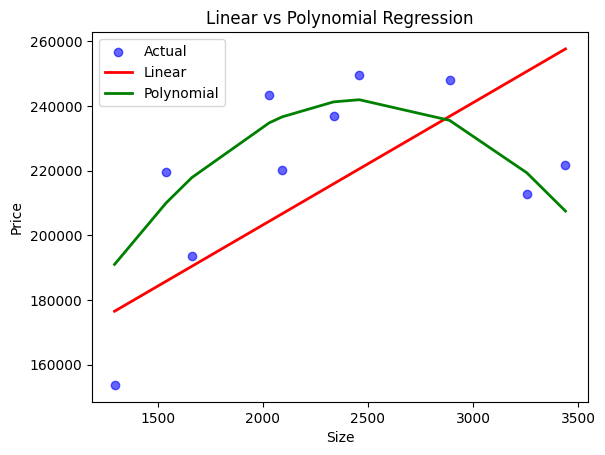

In [36]:
# Actual data
plt.scatter(X_test, y_test,
            color="blue", alpha=0.6, label="Actual")

# Linear prediction
plt.plot(X_test_sorted, linear_model.predict(X_test_sorted),
         color="red", label="Linear", linewidth=2)

# Polynomial prediction
plt.plot(X_test_sorted, poly_model.predict(X_test_poly_sorted),
         color="green", label="Polynomial", linewidth=2)

plt.title("Linear vs Polynomial Regression")
plt.xlabel("Size")
plt.ylabel("Price")
plt.legend()
plt.show()

Green curve fits data better than red straight line.


In [37]:
# Degree Selection — Overfitting Warning
# Try different degrees and compare R2
degrees = [1, 2, 3, 4, 5]

for degree in degrees:
    poly    = PolynomialFeatures(degree=degree)
    X_tr_p  = poly.fit_transform(X_train)
    X_te_p  = poly.transform(X_test)

    model   = LinearRegression()
    model.fit(X_tr_p, y_train)

    train_r2 = r2_score(y_train, model.predict(X_tr_p))
    test_r2  = r2_score(y_test,  model.predict(X_te_p))

    print(f"Degree {degree} — Train R2: {train_r2:.4f}  Test R2: {test_r2:.4f}")

Degree 1 — Train R2: 0.5507  Test R2: 0.0138
Degree 2 — Train R2: 0.8468  Test R2: 0.6231
Degree 3 — Train R2: 0.8520  Test R2: 0.6445
Degree 4 — Train R2: 0.8523  Test R2: 0.6406
Degree 5 — Train R2: 0.8505  Test R2: 0.6385


What you will see:

Degree 1 — Train R2: 0.85   Test R2: 0.83   — underfitting\
Degree 2 — Train R2: 0.97   Test R2: 0.96   — good fit ✅\
Degree 3 — Train R2: 0.98   Test R2: 0.95   — still ok\
Degree 4 — Train R2: 0.99   Test R2: 0.80   — overfitting starts\
Degree 5 — Train R2: 0.99   Test R2: 0.60   — overfitting bad\
High degree = train R2 goes up but test R2 goes down = overfitting.

In [38]:
# Predict price for house of 2000 sqft
new_size      = pd.DataFrame([[2000]], columns=["size"])
poly          = PolynomialFeatures(degree=2)
poly.fit(X_train)   # fit on training data
new_size_poly = poly.transform(new_size)

predicted_price = poly_model.predict(new_size_poly)
print(f"Predicted price for 2000 sqft: {predicted_price[0]:,.0f}")

Predicted price for 2000 sqft: 233,746
